# Artificial Intelligence & Machine Learning – Task 3
## Model Validation, Overfitting Control & Hyperparameter Tuning

**Project:** Enhanced House Price Prediction System  
**Dataset:** California Housing Dataset  
**Author:** Shivangi Arya

This notebook extends Task 2 by validating the Decision Tree model, demonstrating overfitting, applying 5-fold cross-validation, tuning hyperparameters with GridSearchCV, and comparing the optimized model with the Task 2 Linear and Ridge baselines.

### 1. Import Libraries

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42
BASE = Path.cwd()
DATA_PATH = BASE / 'data' / 'california_housing.csv'
RESULTS_DIR = BASE / 'results'
FIGURES_DIR = BASE / 'figures'
MODELS_DIR = BASE / 'models'
for p in (RESULTS_DIR, FIGURES_DIR, MODELS_DIR): p.mkdir(exist_ok=True)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


### 2. Load and Prepare the California Housing Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
display(df.head())
print('Missing values:', int(df.isna().sum().sum()))


Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Missing values: 0


In [3]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))


Training samples: 16512
Testing samples: 4128


### 3. Task 2 Baseline Models

In [4]:
linear_model = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
ridge_model = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

lr_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)

baseline = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'RMSE': [rmse(y_test, lr_pred), rmse(y_test, ridge_pred)],
    'R2 Score': [r2_score(y_test, lr_pred), r2_score(y_test, ridge_pred)]
})
display(baseline.round(4))


,Model,RMSE,R2 Score
0,Linear Regression,0.7456,0.5758
1,Ridge Regression,0.7456,0.5758


### 4. Detect Overfitting with an Unrestricted Decision Tree

Train RMSE: 0.0000
Test RMSE:  0.7037
Train R2:   1.0000
Test R2:    0.6221


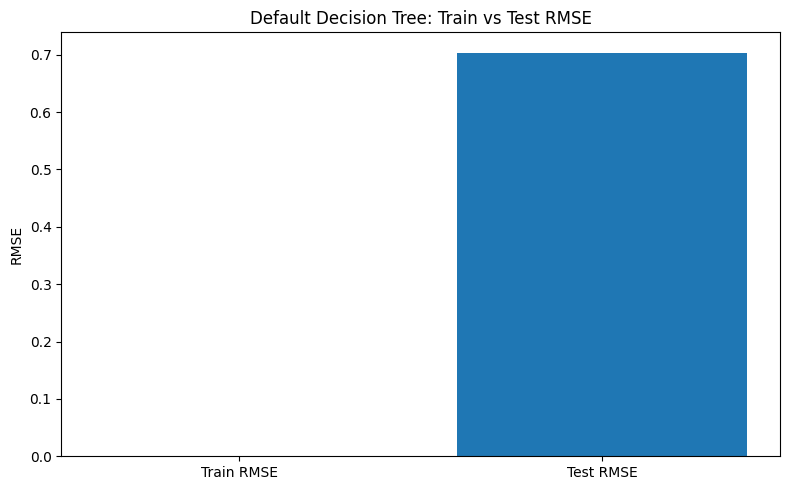

In [5]:
default_tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
default_tree.fit(X_train, y_train)
default_train_rmse = rmse(y_train, default_tree.predict(X_train))
default_test_rmse = rmse(y_test, default_tree.predict(X_test))
default_train_r2 = r2_score(y_train, default_tree.predict(X_train))
default_test_r2 = r2_score(y_test, default_tree.predict(X_test))

print(f'Train RMSE: {default_train_rmse:.4f}')
print(f'Test RMSE:  {default_test_rmse:.4f}')
print(f'Train R2:   {default_train_r2:.4f}')
print(f'Test R2:    {default_test_r2:.4f}')

plt.figure(figsize=(8,5))
plt.bar(['Train RMSE','Test RMSE'], [default_train_rmse, default_test_rmse])
plt.title('Default Decision Tree: Train vs Test RMSE')
plt.ylabel('RMSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'overfitting_train_vs_test.png', dpi=180)
plt.show()


**Observation:** The unrestricted tree fits the training data almost perfectly (R² ≈ 1.00) while its test error is much larger. This large train–test gap is clear evidence of overfitting.

### 5. Five-Fold Cross-Validation

In [6]:
cv_scores = -cross_val_score(
    default_tree, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
cv_summary = pd.DataFrame({'Fold': range(1,6), 'RMSE': cv_scores})
display(cv_summary.round(4))
print(f'Mean CV RMSE: {cv_scores.mean():.4f}')
print(f'Std CV RMSE:  {cv_scores.std():.4f}')
cv_summary.to_csv(RESULTS_DIR/'cross_validation_scores.csv', index=False)


,Fold,RMSE
0,1,0.7534
1,2,0.7344
2,3,0.7017
3,4,0.7287
4,5,0.7017


Mean CV RMSE: 0.7240
Std CV RMSE:  0.0199


### 6. Hyperparameter Tuning with GridSearchCV

The search follows the Task 3 brief: `max_depth = [3, 5, 7, 10]`, `min_samples_split = [2, 5, 10]`, scoring by negative RMSE, with 5-fold cross-validation. A pipeline keeps scaling inside each training fold to avoid data leakage.

In [7]:
tree_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
])
param_grid = {
    'model__max_depth': [3,5,7,10],
    'model__min_samples_split': [2,5,10]
}

grid = GridSearchCV(
    tree_pipeline, param_grid=param_grid, scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, return_train_score=True
)
grid.fit(X_train, y_train)
print('Best parameters:', grid.best_params_)
print(f'Best 5-fold CV RMSE: {-grid.best_score_:.4f}')


Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 10}
Best 5-fold CV RMSE: 0.6375


In [8]:
grid_results = pd.DataFrame(grid.cv_results_)
grid_results['mean_test_RMSE'] = -grid_results['mean_test_score']
grid_results['std_test_RMSE'] = grid_results['std_test_score']
grid_results['mean_train_RMSE'] = -grid_results['mean_train_score']
grid_results = grid_results.sort_values('mean_test_RMSE')
display(grid_results[['param_model__max_depth','param_model__min_samples_split','mean_train_RMSE','mean_test_RMSE','std_test_RMSE']].head(10).round(4))
grid_results.to_csv(RESULTS_DIR/'grid_search_results.csv', index=False)
pd.DataFrame([{'Parameter':k,'Best Value':v} for k,v in grid.best_params_.items()]).to_csv(RESULTS_DIR/'best_parameters.csv', index=False)


,param_model__max_depth,param_model__min_samples_split,mean_train_RMSE,mean_test_RMSE,std_test_RMSE
11,10,10,0.4633,0.6375,0.0068
10,10,5,0.4538,0.6388,0.0129
9,10,2,0.4494,0.6432,0.0079
6,7,2,0.6010,0.6528,0.0129
8,7,10,0.6025,0.6535,0.0139
7,7,5,0.6013,0.6536,0.0142
3,5,2,0.6916,0.7127,0.0140
4,5,5,0.6916,0.7127,0.0140
5,5,10,0.6919,0.7127,0.0133
1,3,5,0.7848,0.7957,0.0122


### 7. Evaluate the Optimized Decision Tree

Tuned train RMSE: 0.4804
Tuned test RMSE:  0.6454
Tuned train R2:   0.8274
Tuned test R2:    0.6822
Overfit gap:      0.1650


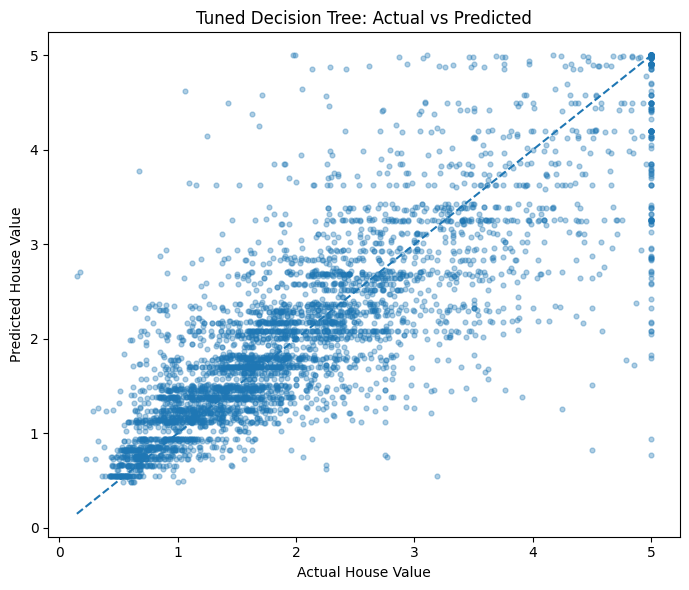

In [9]:
best_tree = grid.best_estimator_
best_pred = best_tree.predict(X_test)
tuned_train_rmse = rmse(y_train, best_tree.predict(X_train))
tuned_test_rmse = rmse(y_test, best_pred)
tuned_train_r2 = r2_score(y_train, best_tree.predict(X_train))
tuned_test_r2 = r2_score(y_test, best_pred)

print(f'Tuned train RMSE: {tuned_train_rmse:.4f}')
print(f'Tuned test RMSE:  {tuned_test_rmse:.4f}')
print(f'Tuned train R2:   {tuned_train_r2:.4f}')
print(f'Tuned test R2:    {tuned_test_r2:.4f}')
print(f'Overfit gap:      {tuned_test_rmse - tuned_train_rmse:.4f}')

plt.figure(figsize=(7,6))
plt.scatter(y_test, best_pred, alpha=0.35, s=12)
mn, mx = min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())
plt.plot([mn,mx],[mn,mx], linestyle='--')
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Tuned Decision Tree: Actual vs Predicted')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'actual_vs_predicted_tuned_tree.png', dpi=180)
plt.show()


### 8. Final Model Comparison

,Model,RMSE,R2 Score,Overfit Gap
0,Linear Regression,0.7456,0.5758,NaN
1,Ridge Regression,0.7456,0.5758,NaN
2,Tuned Decision Tree,0.6454,0.6822,0.165


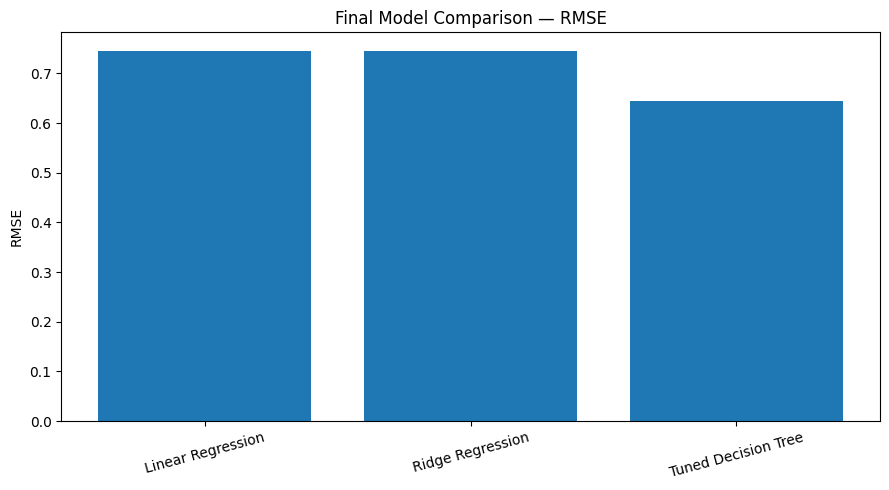

In [10]:
comparison = pd.DataFrame({
    'Model':['Linear Regression','Ridge Regression','Tuned Decision Tree'],
    'RMSE':[rmse(y_test,lr_pred), rmse(y_test,ridge_pred), tuned_test_rmse],
    'R2 Score':[r2_score(y_test,lr_pred), r2_score(y_test,ridge_pred), tuned_test_r2],
    'Overfit Gap':[np.nan,np.nan,tuned_test_rmse-tuned_train_rmse]
})
display(comparison.round(4))
comparison.to_csv(RESULTS_DIR/'model_comparison.csv', index=False)

plt.figure(figsize=(9,5))
plt.bar(comparison['Model'], comparison['RMSE'])
plt.title('Final Model Comparison — RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'model_comparison_rmse.png', dpi=180)
plt.show()


### 9. Save Final Model and Results

In [11]:
joblib.dump(best_tree, MODELS_DIR/'tuned_decision_tree.joblib')
summary = pd.DataFrame({
    'Metric':[
        'Default Tree Train RMSE','Default Tree Test RMSE','Default Tree Train R2','Default Tree Test R2',
        'Default Tree 5-Fold CV Mean RMSE','Default Tree 5-Fold CV Std RMSE',
        'Tuned Tree Train RMSE','Tuned Tree Test RMSE','Tuned Tree Train R2','Tuned Tree Test R2',
        'Tuned Tree 5-Fold CV Mean RMSE','Tuned Tree Test Overfit Gap'
    ],
    'Value':[default_train_rmse,default_test_rmse,default_train_r2,default_test_r2,cv_scores.mean(),cv_scores.std(),
             tuned_train_rmse,tuned_test_rmse,tuned_train_r2,tuned_test_r2,-grid.best_score_,tuned_test_rmse-tuned_train_rmse]
})
summary.to_csv(RESULTS_DIR/'task3_summary.csv', index=False)
print('Final model saved to:', MODELS_DIR/'tuned_decision_tree.joblib')


Final model saved to: /mnt/data/task3_final_build/models/tuned_decision_tree.joblib


## Conclusion

The unrestricted Decision Tree clearly overfits the training set. Five-fold cross-validation provides a more reliable estimate of generalization, and GridSearchCV identifies `max_depth=10` and `min_samples_split=10` as the best combination in the specified search space. The tuned tree reduces test RMSE from the unrestricted tree and outperforms the Task 2 Linear and Ridge baselines on the held-out test set. The final tuned Decision Tree is therefore selected as the Task 3 model.